<a href="https://colab.research.google.com/github/dkoravski/ai-travel-planner/blob/main/AI_Travel_Planner_LangGraph_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# AI Travel Planner — мулти-агентна система с LangGraph и LangChain

## Описание на сценария

Този notebook изгражда **мулти-агентна система за планиране на пътувания**, реализирана
като **stateful граф в LangGraph**. Потребителят подава заявка на естествен език
(напр. *„Планирай 5-дневно пътуване до Токио с бюджет €2000 за 2-ма души“*) и системата
преминава през следните стъпки:

- Research Agent (агент-проучвател) — използва инструмент за търсене в Wikipedia, за да проучи дестинацията: най-подходящ сезон, забележителности, културни/практически съвети;
- Literary Planner Agent (агент-планировчик) — използва (а) инструмент за (симулирано) търсене на цени на самолетни билети/хотели и (б) калкулатор за разбивка на бюджета, за да състави подробен дневен маршрут, съобразен с бюджета на потребителя;
- Human-in-the-Loop преглед — графът **спира** изпълнението точно преди да финализира маршрута и изисква одобрение (или обратна връзка) от човек. Ако човекът поиска промени, графът се връща към Planner Agent-а, който ревизира маршрута, вземайки предвид обратната връзка — и цикълът се повтаря, докато маршрутът бъде одобрен;
- Финализиране — след одобрение, графът произвежда финалния, потвърден маршрут.

### Архитектура на графа

```
START → research_agent → planner_agent → human_gate ─┬─(одобрено)──→ finalize → END
                              ▲                       │
                              └────(иска се ревизия)──┘
```

Целият процес (включително паузата при `human_gate`) се управлява от **LangGraph checkpointer
(`MemorySaver`)**, който едновременно осигурява:
- **паметта** на разговора (пълна история на съобщенията между агентите се пази в state-а);
- възможността графът да **спре** (`interrupt_before`) и по-късно да бъде **възобновен** (`update_state` + повторно `invoke`) точно от мястото, където е спрял — това е механизмът зад Human-in-the-Loop.

In [ ]:
!pip install -q -U langgraph langchain langchain-openai langchain-community wikipedia


In [ ]:
import os
import uuid
import random
import time
from typing import TypedDict, Annotated, Optional, List

from langchain_core.messages import AnyMessage, HumanMessage, AIMessage, SystemMessage
from langchain_core.tools import tool
from langchain_community.utilities import WikipediaAPIWrapper
from langchain_openai import ChatOpenAI

from langgraph.graph import StateGraph, END
from langgraph.graph.message import add_messages
from langgraph.checkpoint.memory import MemorySaver
from langchain.agents import create_agent
from google.colab import userdata
from IPython.display import Image, display

model_name = "gpt-4o-mini"


/tmp/ipykernel_12058/2822121165.py:9: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.utilities import WikipediaAPIWrapper


In [ ]:
os.environ["LANGSMITH_TRACING"] = "true"
os.environ["LANGSMITH_ENDPOINT"] ="https://api.smith.langchain.com"
os.environ["LANGSMITH_API_KEY"] = userdata.get("LANGSMITH_API_KEY1")
os.environ["LANGSMITH_PROJECT"] = "Travel Planner"

In [ ]:
def load_openai_key():
    # Зареждаме през Google Colab Secrets
    try:
        api_key = userdata.get("OPENAI_API_KEY")
        if api_key:
            os.environ["OPENAI_API_KEY"] = api_key
            print("OpenAI API ключ зареден от Colab Secrets.")
            return
    except Exception:
        pass

load_openai_key()
assert os.environ.get("OPENAI_API_KEY"), "OPENAI_API_KEY не е зададен!"


OpenAI API ключ зареден от Colab Secrets.


## State на графа

`TripState` е споделеното състояние, което се предава между всички агенти/възли в графа.
Полето `messages` използва reducer-а `add_messages` от LangGraph, който автоматично
**добавя** нови съобщения към историята (вместо да я презаписва) — това е механизмът,
чрез който се поддържа **паметта на разговора** между агентите.

In [ ]:
class TripState(TypedDict):
    user_request: str                              # оригиналната заявка на потребителя
    messages: Annotated[List[AnyMessage], add_messages]  # пълна история/памет на разговора
    research_notes: Optional[str]                  # резултат от Research Agent
    itinerary_draft: Optional[str]                  # текуща чернова на маршрута
    revision_count: int                             # брой направени ревизии
    human_feedback: Optional[str]                   # обратна връзка от човека (ако има)
    approved: Optional[bool]                        # дали човекът е одобрил чернова
    final_itinerary: Optional[str]                  # финалният, одобрен маршрут


## Системни класове и инструменти (Tools)

1. WikipediaAPIWrapper(...) — готов клас от langchain_community, който "обвива" достъпа до Wikipedia: знае как да прати заявка, да вземе резултатите и да ги форматира като текст, който после подаваме на LLM-а. Той използва пакета wikipedia, който е инсталиран в началото. Параметри:
- top_k_results=2 — колко статии от Wikipedia да върне като резултат от търсенето;
- doc_content_chars_max=1200 — максимална дължина (в брой символи) на съдържанието, което взимаме от всяка статия.
2. `wikipedia_search` — обвивка около **вградената** LangChain интеграция с Wikipedia (`WikipediaAPIWrapper`), реален web lookup.
3. `search_flights_and_hotels` — **custom** инструмент (Python функция, обвита с `@tool`), който симулира извикване на реално API за самолетни билети/хотели (mock API call).
4. `estimate_daily_budget` — **custom** инструмент тип „калкулатор“, който разбива общия бюджет по категории на ден на пътник.

In [ ]:
wikipedia_api = WikipediaAPIWrapper(top_k_results=2, doc_content_chars_max=1200)


@tool
def wikipedia_search(query: str) -> str:
    '''Search Wikipedia for background information about a travel destination (best season
    to visit, history, culture, notable facts). Wraps the built-in WikipediaAPIWrapper with
    a couple of retries and a graceful fallback message, so a transient Wikipedia/network
    error never crashes the whole multi-agent workflow.'''
    last_error = None
    for attempt in range(2):
        try:
            return wikipedia_api.run(query)
        except Exception as e:
            last_error = e
            time.sleep(1)
    return (
        f"Wikipedia търсенето за '{query}' не бе успешно в момента (временен проблем: "
        f"{type(last_error).__name__}: {last_error}). Продължи, разчитайки на общи познания "
        "за дестинацията, без да спираш работата."
    )


@tool
def search_flights_and_hotels(
    destination: str, num_days: int, num_travelers: int, currency_symbol: str = "$"
) -> str:
    '''Mock search for flight and hotel prices for a given destination, trip length (days)
    and number of travelers. Simulates a call to a real travel-booking API (e.g.
    Skyscanner/Booking.com) without needing a real key. IMPORTANT: pass currency_symbol
    matching whatever currency the user mentioned in their request (e.g. "$", "€", "£") -
    default is "$" (USD) if the user did not specify a currency.'''
    rng = random.Random(abs(hash(destination.lower().strip())) % (10**6))
    flight_low = rng.randint(250, 500)
    flight_high = flight_low + rng.randint(150, 400)
    hotel_per_night = rng.randint(60, 220)
    c = currency_symbol
    return (
        f"Дестинация: {destination}\n"
        f"Самолетни билети (round-trip, на пътник): {c}{flight_low}-{c}{flight_high}\n"
        f"Хотел (на нощувка, средна категория): {c}{hotel_per_night}\n"
        f"Прогнозна обща цена за настаняване ({num_days} нощувки): {c}{hotel_per_night * num_days}\n"
        f"Прогнозна обща цена за самолетни билети ({num_travelers} пътници): "
        f"{c}{flight_low * num_travelers}-{c}{flight_high * num_travelers}"
    )


@tool
def estimate_daily_budget(
    total_budget: float, num_days: int, num_travelers: int, currency_symbol: str = "$"
) -> str:
    '''Calculator tool: splits a total trip budget across accommodation, food, activities
    and transport, per day and per traveler. IMPORTANT: pass currency_symbol matching
    whatever currency the user mentioned in their request (e.g. "$", "€", "£") - default is
    "$" (USD) if the user did not specify a currency.'''
    if num_days <= 0 or num_travelers <= 0:
        return "Грешка: брой дни и брой пътници трябва да са положителни числа."
    per_day_total = total_budget / num_days
    per_person_per_day = per_day_total / num_travelers
    breakdown = {
        "настаняване": 0.40,
        "храна": 0.25,
        "дейности/атракции": 0.20,
        "транспорт на място": 0.15,
    }
    c = currency_symbol
    lines = [
        f"Общ бюджет: {c}{total_budget:.2f} за {num_days} дни / {num_travelers} пътници",
        f"На ден (общо): {c}{per_day_total:.2f}",
        f"На пътник на ден: {c}{per_person_per_day:.2f}",
        "Препоръчана разбивка на ден:",
    ]
    for category, pct in breakdown.items():
        lines.append(f"  - {category}: {c}{per_day_total * pct:.2f} ({int(pct * 100)}%)")
    return "\n".join(lines)


RESEARCH_TOOLS = [wikipedia_search]
PLANNER_TOOLS = [search_flights_and_hotels, estimate_daily_budget]

# Бърза проверка на custom инструментите (не изисква LLM/API ключ):
print(search_flights_and_hotels.invoke({"destination": "Lisabon", "num_days": 4, "num_travelers": 2, "currency_symbol": "€"}))
print()
print(estimate_daily_budget.invoke({"total_budget": 1200, "num_days": 4, "num_travelers": 2, "currency_symbol": "€"}))


Дестинация: Lisabon
Самолетни билети (round-trip, на пътник): €264-€515
Хотел (на нощувка, средна категория): €119
Прогнозна обща цена за настаняване (4 нощувки): €476
Прогнозна обща цена за самолетни билети (2 пътници): €528-€1030

Общ бюджет: €1200.00 за 4 дни / 2 пътници
На ден (общо): €300.00
На пътник на ден: €150.00
Препоръчана разбивка на ден:
  - настаняване: €120.00 (40%)
  - храна: €75.00 (25%)
  - дейности/атракции: €60.00 (20%)
  - транспорт на място: €45.00 (15%)


## Изграждане на графа (памет + HITL прекъсване):

- `checkpointer=MemorySaver()` дава на графа памет между стъпките (и между pause/resume);
- `interrupt_before=["human_gate"]` графа spira точно преди възела `human_gate` - тоест веднага след като Planner Agent-ът е направил чернова на маршрута, но преди да е финализирана. Това е и нашата Human-in-the-Loop точка.

In [ ]:
checkpointer = MemorySaver()

## Агенти: системни промптове + LLM


In [ ]:
RESEARCHER_SYSTEM_PROMPT = '''Ти си 'Destination Research Agent' - експерт по дестинации за пътуване.
Твоята единствена задача е да проучиш конкретна дестинация, като ЗАДЪЛЖИТЕЛНО използваш
инструмента за Wikipedia търсене, и да обобщиш кратко (в 5-8 изречения/точки):
- най-подходящ сезон/време за посещение,
- 3-5 задължителни забележителности/дейности,
- кратки културни/практически съвети (валута, език, транспорт).
Не съставяй маршрут по дни - това е задача на друг агент. Бъди конкретен и полезен.'''

PLANNER_SYSTEM_PROMPT = '''Ти си 'Itinerary Planner Agent' - експерт по съставяне на пътни маршрути.
Използваш инструментите за (1) търсене на цени на полети/хотели и (2) изчисляване на бюджет,
за да съставиш реалистичен, подробен маршрут по дни (Ден 1, Ден 2, ...), който пасва на бюджета
и предпочитанията на потребителя. Ако получиш обратна връзка от предишен преглед от човек,
ЗАДЪЛЖИТЕЛНО ревизирай маршрута така, че да я отразява. Форматирай маршрута ясно и четимо.

ВАЖНО за валутата: потребителят може да посочи бюджет в различна валута (напр. "$2000",
"€1500", "£1200"). Определи символа на валутата от заявката на потребителя и ЗАДЪЛЖИТЕЛНО
подавай точно този символ като параметър currency_symbol на двата инструмента (по подразбиране
е "$", ако потребителят не е посочил валута). Използвай СЪЩИЯ символ навсякъде в текста на
финалния маршрут, за да няма несъответствие между валутите.'''

llm = ChatOpenAI(model=model_name, temperature=0.4)

research_agent = create_agent(
    llm,
    tools=RESEARCH_TOOLS,
    checkpointer=checkpointer,
    system_prompt=RESEARCHER_SYSTEM_PROMPT,
    debug=True
    )

planner_agent = create_agent(
    llm,
    tools=PLANNER_TOOLS,
    checkpointer=checkpointer,
    system_prompt=PLANNER_SYSTEM_PROMPT,
    debug=True
    )

## Nodes

Всеки node извиква съответния под-агент и записва резултата в общия `TripState`, включително добавя запис в `messages` (паметта на целия разговор/workflow).

In [ ]:
def research_node(state: TripState) -> dict:
    sub_result = research_agent.invoke({
        "messages": [HumanMessage(content=(
            f"Потребителска заявка: {state['user_request']}\n\n"
            "Проучи дестинацията, спазвайки инструкциите в системния промпт."
        ))]
    })
    notes = sub_result["messages"][-1].content
    return {
        "research_notes": notes,
        "messages": [AIMessage(content=f"[Research Agent]\n{notes}")],
    }


def planner_node(state: TripState) -> dict:
    feedback_block = ""
    if state.get("human_feedback"):
        feedback_block = (
            "\n\nОбратна връзка от потребителя за предходната чернова "
            f"(ЗАДЪЛЖИТЕЛНО я вземи предвид):\n{state['human_feedback']}"
        )
    prior_draft = ""
    if state.get("itinerary_draft"):
        prior_draft = f"\n\nПредходна чернова на маршрута:\n{state['itinerary_draft']}"

    prompt = (
        f"Заявка на потребителя: {state['user_request']}\n\n"
        f"Проучване за дестинацията:\n{state.get('research_notes', '(няма)')}"
        f"{prior_draft}{feedback_block}\n\n"
        "Изгради/ревизирай подробен дневен маршрут."
    )
    sub_result = planner_agent.invoke({"messages": [HumanMessage(content=prompt)]})
    draft = sub_result["messages"][-1].content
    new_revision_count = state.get("revision_count", 0) + (1 if state.get("human_feedback") else 0)
    return {
        "itinerary_draft": draft,
        "revision_count": new_revision_count,
        "human_feedback": None,
        "messages": [AIMessage(content=f"[Planner Agent - чернова №{new_revision_count + 1}]\n{draft}")],
    }


def human_gate_node(state: TripState) -> dict:
    # No-op "passthrough" възел. Паузата се случва защото графът е компилиран с
    # interrupt_before=["human_gate"]; докато графът е паузиран, външен код записва
    # 'approved'/'human_feedback' в state-а чрез update_state(), преди да продължи (resume).
    return {}


def finalize_node(state: TripState) -> dict:
    final_text = f"МАРШРУТЪТ Е ОДОБРЕН ОТ ПОТРЕБИТЕЛЯ.\n\n{state['itinerary_draft']}"
    return {
        "final_itinerary": final_text,
        "messages": [AIMessage(content=final_text)],
    }


def route_after_human_gate(state: TripState) -> str:
    return "finalize" if state.get("approved") else "planner_agent"


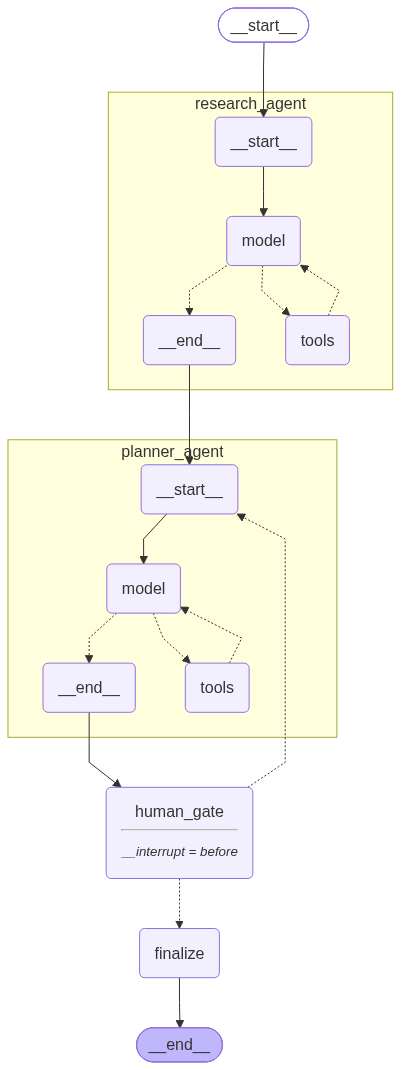

In [ ]:
graph_builder = StateGraph(TripState)
graph_builder.add_node("research_agent", research_node)
graph_builder.add_node("planner_agent", planner_node)
graph_builder.add_node("human_gate", human_gate_node)
graph_builder.add_node("finalize", finalize_node)

graph_builder.set_entry_point("research_agent")
graph_builder.add_edge("research_agent", "planner_agent")
graph_builder.add_edge("planner_agent", "human_gate")
graph_builder.add_conditional_edges(
    "human_gate",
    route_after_human_gate,
    {"finalize": "finalize", "planner_agent": "planner_agent"},
)
graph_builder.add_edge("finalize", END)

travel_graph = graph_builder.compile(checkpointer=checkpointer, interrupt_before=["human_gate"])

# display(Image(travel_graph.get_graph().draw_mermaid_png()))
display(Image(travel_graph.get_graph(xray=True).draw_mermaid_png()))


## Функция: `execute_workflow`

Това е основната входна точка : приема **един стринг параметър** `user_request`. Отвътре тя:

- стартира графа с ново `thread_id`;
- изпълнява го, докато той спре на `human_gate` (чернова на маршрута готова за преглед);
- взима отговор от човека чрез `human_input_fn` (по подразбиране истинско `input()` за интерактивна употреба в Colab; тестовите кейси подават симулирана функция, за да могат да демонстрират HITL процеса **автоматично и възпроизводимо**, без да блокират notebook);
- записва `approved`/`human_feedback` в state-а (`update_state`) и **възобновява** графа (`invoke(None, config)`);
- повтаря 3-4 пъти, докато потребителят одобри (или се стигне `max_revisions`).

In [ ]:
APPROVE_KEYWORDS = {"одобрявам", "одобрено", "approve", "approved", "yes", "да", "ok", "ок", "потвърждавам"}


def default_human_input(itinerary_draft: str) -> str:
    print("\n" + "=" * 70)
    print("МАРШРУТ ЗА ЧОВЕШКИ ПРЕГЛЕД:\n")
    print(itinerary_draft)
    print("=" * 70)
    return input("\nОдобрявате ли? Напишете 'одобрявам' или опишете какво да се промени: ")


def execute_workflow(user_request: str, human_input_fn=None, max_revisions: int = 3, verbose: bool = True) -> dict:
    '''Основна входна функция на мулти-агентния workflow.

    Параметри
    ----------
    user_request : str
        Заявката на потребителя на естествен език, напр.
        "Планирай 5-дневно пътуване до Токио с бюджет €2000 за 2-ма души."
    human_input_fn : callable, optional
        Функция (itinerary_draft: str) -> str, връщаща отговора на човека при преглед.
        По подразбиране използва истинско input() (интерактивен режим). Тестовите кейси
        подават функция със симулирани отговори, за да демонстрират approve/revise потока
        детерминистично, без да чакат реално въвеждане.
    max_revisions : int
        Предпазен таван на броя ревизии (за да не се получи безкраен цикъл).

    Връща: финалното state на графа (dict), включващо 'final_itinerary'.
    '''
    if human_input_fn is None:
        human_input_fn = default_human_input

    thread_id = str(uuid.uuid4())
    config = {"configurable": {"thread_id": thread_id}}

    initial_state = {
        "user_request": user_request,
        "messages": [HumanMessage(content=user_request)],
        "revision_count": 0,
        "human_feedback": None,
        "approved": None,
    }

    if verbose:
        print(f"\n🧭  Стартиране на workflow за заявка: {user_request!r}")

    state = travel_graph.invoke(initial_state, config)

    revisions = 0
    while True:
        snapshot = travel_graph.get_state(config)
        awaiting_review = bool(snapshot.next) and "human_gate" in snapshot.next
        if not awaiting_review:
            break

        response = human_input_fn(state["itinerary_draft"])
        approved = response.strip().lower() in APPROVE_KEYWORDS

        if verbose:
            verdict = "ОДОБРЕНО ✅" if approved else "ИСКА СЕ РЕВИЗИЯ 🔁"
            print(f"\n👤 Отговор на потребителя: {response!r}  ->  {verdict}")

        travel_graph.update_state(config, {
            "approved": approved,
            "human_feedback": None if approved else response,
        })
        state = travel_graph.invoke(None, config)

        if approved:
            break
        revisions += 1
        if revisions >= max_revisions:
            if verbose:
                print("⚠️  Достигнат е максималният брой ревизии.")
            break
    state["thread_id"] = thread_id
    if verbose:
        print("\n✅ Workflow завършен.\n")
    return state


## Тестови сценарии (5 теста)

За да демонстрираме Human-in-the-Loop **автоматично** (без notebook-а да чака реално
въвеждане от клавиатурата при "Run all"), подаваме на `execute_workflow` симулирана
`human_input_fn`, която връща предварително зададени отговори — точно както истински
потребител би написал в диалога. Помощната функция `simulated_reviewer` по-долу прави
това.

- **Тест 1, 4** → одобрение веднага (approve).
- **Тест 2, 3** → обратна връзка → ревизия → одобрение (revise → approve).
- **Тест 5** → две последователни обратни връзки → две ревизии → одобрение (демонстрира
  цикъла с повече от една ревизия).

За всеки тест накрая се отпечатва и `messages` – пълната памет на разговора между агентите
и човека за тази заявка.

In [ ]:
def simulated_reviewer(*responses):
    '''Връща функция, която на всяко повикване дава следващия отговор от 'responses'
    (симулира човек, отговарящ на последователни прегледи на маршрута).'''
    it = iter(responses)
    def _fn(itinerary_draft: str) -> str:
        answer = next(it)
        print("\n" + "=" * 70)
        print("МАРШРУТ ЗА ЧОВЕШКИ ПРЕГЛЕД:\n")
        print(itinerary_draft)
        print("=" * 70)
        print(f"[СИМУЛИРАН ЧОВЕШКИ ОТГОВОР] -> {answer!r}")
        return answer
    return _fn


def print_memory_transcript(result_state: dict) -> None:
    print("\n--- ПЪЛНА ПАМЕТ НА РАЗГОВОРА (messages) ---")
    for m in result_state["messages"]:
        role = m.__class__.__name__
        preview = m.content if len(m.content) < 300 else m.content[:300] + " ..."
        print(f"[{role}] {preview}\n")


In [ ]:
# Тест 1: Токио, одобрение веднага ---
result_1 = execute_workflow(
    "Планирай 5-дневно пътуване до Токио, Япония, за 2-ма възрастни, с бюджет €2000. "
    "Искаме комбинация от култура и модерен градски живот.",
    human_input_fn=simulated_reviewer("одобрявам"),
)
print(result_1["final_itinerary"])
print_memory_transcript(result_1)



🧭  Стартиране на workflow за заявка: 'Планирай 5-дневно пътуване до Токио, Япония, за 2-ма възрастни, с бюджет €2000. Искаме комбинация от култура и модерен градски живот.'
[values] {'messages': [HumanMessage(content='Потребителска заявка: Планирай 5-дневно пътуване до Токио, Япония, за 2-ма възрастни, с бюджет €2000. Искаме комбинация от култура и модерен градски живот.\n\nПроучи дестинацията, спазвайки инструкциите в системния промпт.', additional_kwargs={}, response_metadata={}, id='d97272fa-327a-4be6-af94-e0ed32ba9fea')]}
[updates] {'model': {'messages': [AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 14, 'prompt_tokens': 344, 'total_tokens': 358, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_na

In [ ]:
# Тест 2: Париж, обратна връзка -> ревизия -> одобрение ---
result_2 = execute_workflow(
    "Искам романтичен уикенд (3 дни) в Париж, Франция, за 2-ма, бюджет €1500.",
    human_input_fn=simulated_reviewer(
        "Маршрутът е твърде натоварен - искам повече свободно време и по-малко музеи.",
        "одобрявам",
    ),
)
print(result_2["final_itinerary"])
print_memory_transcript(result_2)


In [ ]:
# Тест 3: Родопите, 2-ма, обратна връзка за бюджета -> ревизия -> одобрение ---
result_3 = execute_workflow(
    "Планирай 3-дневно семейно пътуване до Родопите, България, за 2-ма възрастни, "
    "бюджет €600.",
    human_input_fn=simulated_reviewer(
        "Настаняването изглежда твърде скъпо за нашия бюджет - предложи по-икономичен вариант.",
        "одобрявам",
    ),
)
print(result_3["final_itinerary"])
print_memory_transcript(result_3)


In [ ]:
# Тест 4: Бали, меден месец, одобрение веднага ---
result_4 = execute_workflow(
    "Планирай 7-дневен меден месец на остров Бали, Индонезия, за 2-ма, бюджет €4000, "
    "искаме плажове, спа и малко приключения.",
    human_input_fn=simulated_reviewer("одобрявам"),
)
print(result_4["final_itinerary"])
print_memory_transcript(result_4)


In [ ]:
# Тест 5: Ню Йорк, бизнес + свободно време, ДВЕ последователни ревизии -> одобрение ---
result_5 = execute_workflow(
    "Планирай 4-дневно пътуване до Ню Йорк, САЩ, за 1 човек (бизнес пътуване с малко "
    "свободно време), бюджет €1800.",
    human_input_fn=simulated_reviewer(
        "Добави повече препоръки за музеи и култура през свободното време.",
        "Все още искам поне един ден изцяло свободен, без планирани активности.",
        "одобрявам",
    ),
)
print(result_5["final_itinerary"])
print(f"\nОбщ брой ревизии за този тест: {result_5['revision_count']}")
print_memory_transcript(result_5)


In [ ]:
# Визуализация на checkpointer-а (паметта) за Тест 1 (Токио)
config_1 = {"configurable": {"thread_id": result_1["thread_id"]}}

print(f"thread_id на Тест 1: {result_1['thread_id']}\n")

for checkpoint_tuple in checkpointer.list(config_1):
    values = checkpoint_tuple.checkpoint.get("channel_values", {})
    ns = checkpoint_tuple.config["configurable"].get("checkpoint_ns") or "(главен граф)"
    print(
        f"стъпка={checkpoint_tuple.metadata.get('step'):>2}  "
        f"namespace={ns:<45}  "
        f"approved={values.get('approved')}  "
        f"revision_count={values.get('revision_count')}  "
        f"има_чернова={bool(values.get('itinerary_draft'))}"
    )

thread_id на Тест 1: 8cf1e513-47aa-4077-8a54-fcf13a200872

стъпка= 5  namespace=(главен граф)                                  approved=True  revision_count=0  има_чернова=True
стъпка= 4  namespace=(главен граф)                                  approved=True  revision_count=0  има_чернова=True
стъпка= 3  namespace=(главен граф)                                  approved=True  revision_count=0  има_чернова=True
стъпка= 2  namespace=(главен граф)                                  approved=None  revision_count=0  има_чернова=True
стъпка= 1  namespace=(главен граф)                                  approved=None  revision_count=0  има_чернова=False
стъпка= 0  namespace=(главен граф)                                  approved=None  revision_count=0  има_чернова=False
стъпка=-1  namespace=(главен граф)                                  approved=None  revision_count=None  има_чернова=False
стъпка= 9  namespace=research_agent:633e108e-a61e-d26a-74aa-5ff69f528383  approved=None  revision_count=None 

## Действителен интерактивен режим

Клетката по-долу извиква `execute_workflow` **без** симулирана `human_input_fn`, което
означава, че ще използва действителен `input()` — notebook-а ще спре и ще чака реален вход "одобрявам" или обратна връзка.

In [ ]:
# Изисква реално въвеждане в Colab:
my_result = execute_workflow("Планирай 4-дневно пътуване до Виена, Австрия, за 2-ма, бюджет €1600.")
print(my_result["final_itinerary"])


## Резюме

Този notebook демонстрира мулти-агентен workflow с LangGraph :

- **Стейт (`TripState`)**, споделян между агентите, с памет на разговора (`messages` +
  `MemorySaver` checkpointer);
- Два специализирани агента (`research_agent`, `planner_agent`), всеки със собствена роля, system prompt и инструменти;
- Три инструмента (1 вграден Wikipedia + 2 custom: mock цени на полети/хотели и бюджетен калкулатор);
- Human-in-the-Loop преглед преди финализиране на маршрута, с реален цикъл
  ревизия → нов преглед → одобрение;
- execute_workflow (user_request) като единна входна точка, с логика за пауза/
  получаване на обратна връзка/възобновяване на графа;
- 5 тестови сценария, демонстриращи както директно одобрение, така и една или две последователни ревизии;
- Сигурност: API ключът се зарежда от Colab Secrets/environment variables, никога не е записан директно в кода.
